# GHI Prediction System — Final_Daily.xlsx

This notebook trains a production-ready Global Horizontal Irradiance (GHI) prediction model
on `Final_Daily.xlsx` (daily-resolution solar + meteorological data, 2022–2025).

**Data quality findings used to design this pipeline:**
- Target (`GHI_W_Avg_mean`) is missing in 504/1461 rows. **All of 2024 has zero GHI data**
  (sensor outage) — these rows are dropped, not imputed, since there is no ground truth to learn from.
- `GHI_W_Avg_min/max/std` are derived from the same readings as the target → **dropped as leakage**.
- `CloudCover_L2/L3` and `CloudBaseHeight_L2/L3` are missing when that cloud layer simply
  wasn't present that day (not sensor failure) → filled with physically meaningful values
  (0 cover / max height) plus a `_missing` indicator flag, not mean-imputed.
- `Suntime_Tot_sum` is extremely predictive (correlation ≈ 0.88 with GHI) but is missing in
  exactly the rows with missing GHI. Two model variants are trained: **with** Suntime (best
  accuracy, use when you have ground sensor data) and **without** Suntime (weather/forecast-only,
  use for forward prediction when sunshine-duration isn't available at inference time).
- The dataset is small (957 usable rows) relative to its 70+ features, so this notebook favors
  well-regularized tree ensembles (Random Forest / XGBoost / LightGBM) over deep learning, and
  evaluates with a **chronological holdout** (not random split) so no future information leaks
  into training.


## 1. Setup

In [ ]:
!pip install -q xgboost lightgbm shap openpyxl


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import KFold
import xgboost as xgb
import lightgbm as lgb
import shap
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
pd.set_option('display.max_columns', 50)


## 2. Load data

Upload `Final_Daily.xlsx` to the Colab file browser (left sidebar) before running this cell,
or mount Google Drive and update the path.

In [ ]:
FILE_PATH = 'Final_Daily.xlsx'
df = pd.read_excel(FILE_PATH, sheet_name='Daily_Data')
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df = df.sort_values('Timestamp').reset_index(drop=True)

print(f"Loaded {len(df)} rows, {df.shape[1]} columns")
print(f"Date range: {df['Timestamp'].min().date()} to {df['Timestamp'].max().date()}")
df.head()


Loaded 1461 rows, 74 columns
Date range: 2022-01-01 to 2025-12-31


,Timestamp,year,month,day,day_of_year,week_of_year,GHI_W_Avg_mean,GHI_W_Avg_min,GHI_W_Avg_max,GHI_W_Avg_std,Suntime_Tot_sum,AirTemp_C_mean,AirTemp_C_min,AirTemp_C_max,AirTemp_C_std,DewPoint_C_mean,DewPoint_C_min,DewPoint_C_max,DewPoint_C_std,RH_pct_mean,RH_pct_min,RH_pct_max,RH_pct_std,ApparentTemp_F_mean,ApparentTemp_F_min,...,CloudBaseHeight_L1_ft_mean,CloudBaseHeight_L1_ft_min,CloudBaseHeight_L1_ft_max,CloudBaseHeight_L2_ft_mean,CloudBaseHeight_L2_ft_min,CloudBaseHeight_L2_ft_max,CloudBaseHeight_L3_ft_mean,CloudBaseHeight_L3_ft_min,CloudBaseHeight_L3_ft_max,temp_range,temp_mean,humidity_range,wind_variability,cloud_total_mean,cloud_total_max,cloud_total_std,cloud_variability_index,lowest_cloud_height,highest_cloud_height,cloud_height_range,cloud_transmission_index,month_sin,month_cos,doy_sin,doy_cos
0,2022-01-01,2022,1,1,1,52,135.729410,0.0,730.8,189.310613,3.461,26.770833,24.0,29.0,1.402727,25.125000,24.0,28.0,0.761438,90.987917,74.44,100.0,6.735154,84.878542,75.2,...,1933.333333,1800.0,2000.0,6479.166667,2500.0,10000.0,9636.363636,8000.0,10000.0,5.0,26.770833,25.56,4.811283,3.972854,6.0,0.744762,0.187463,1933.333333,9636.363636,7703.030303,0.503393,0.5,0.866025,0.017202,0.999852
1,2022-01-02,2022,1,2,2,52,175.838806,0.0,885.0,259.585781,5.601,26.500000,24.0,30.0,2.221749,23.854167,23.0,27.0,0.771558,86.304167,66.15,100.0,11.724081,83.072917,75.2,...,1979.166667,1800.0,2000.0,7222.222222,2500.0,10000.0,10000.000000,10000.0,10000.0,6.0,26.500000,33.85,4.586727,3.328704,6.0,1.180586,0.354668,1979.166667,10000.000000,8020.833333,0.583912,0.5,0.866025,0.034398,0.999408
2,2022-01-03,2022,1,3,3,1,166.998389,0.0,856.0,232.679798,7.011,25.979167,23.0,30.0,2.320029,22.395833,20.0,26.0,1.567483,82.238958,55.04,100.0,15.453975,80.525833,73.4,...,2000.000000,2000.0,2000.0,10000.000000,10000.0,10000.0,NaN,NaN,NaN,7.0,25.979167,44.96,4.328917,3.143939,6.0,1.003874,0.319304,2000.000000,10000.000000,8000.000000,0.607008,0.5,0.866025,0.051584,0.998669
3,2022-01-04,2022,1,4,4,1,171.586000,0.0,837.0,262.015872,6.416,25.229167,22.0,29.0,2.363189,21.083333,19.0,24.0,1.381232,79.576042,54.80,100.0,16.218180,78.370417,71.6,...,2000.000000,2000.0,2000.0,10000.000000,10000.0,10000.0,NaN,NaN,NaN,7.0,25.229167,45.20,4.678846,3.083333,3.5,0.498224,0.161586,2000.000000,10000.000000,8000.000000,0.614583,0.5,0.866025,0.068755,0.997634
4,2022-01-05,2022,1,5,5,1,135.382021,0.0,788.4,189.762136,4.759,25.270833,22.0,29.0,2.190303,22.375000,22.0,23.0,0.489246,84.899792,65.95,100.0,11.794701,79.210208,71.6,...,2000.000000,2000.0,2000.0,8392.857143,2500.0,10000.0,10000.000000,10000.0,10000.0,7.0,25.270833,34.05,3.503868,2.926587,3.5,0.675626,0.230858,2000.000000,10000.000000,8000.000000,0.634177,0.5,0.866025,0.085906,0.996303


## 3. Data quality check

Missing target by year:
Timestamp
2022    100
2023     32
2024    366
2025      6
Name: GHI_W_Avg_mean, dtype: int64

Total rows: 1461 | Rows with valid target: 957

Target stats (valid rows): 
count    957.000000
mean     197.459138
std       72.232200
min        0.000000
25%      156.006563
50%      210.595382
75%      253.271364
max      372.504435
Name: GHI_W_Avg_mean, dtype: float64


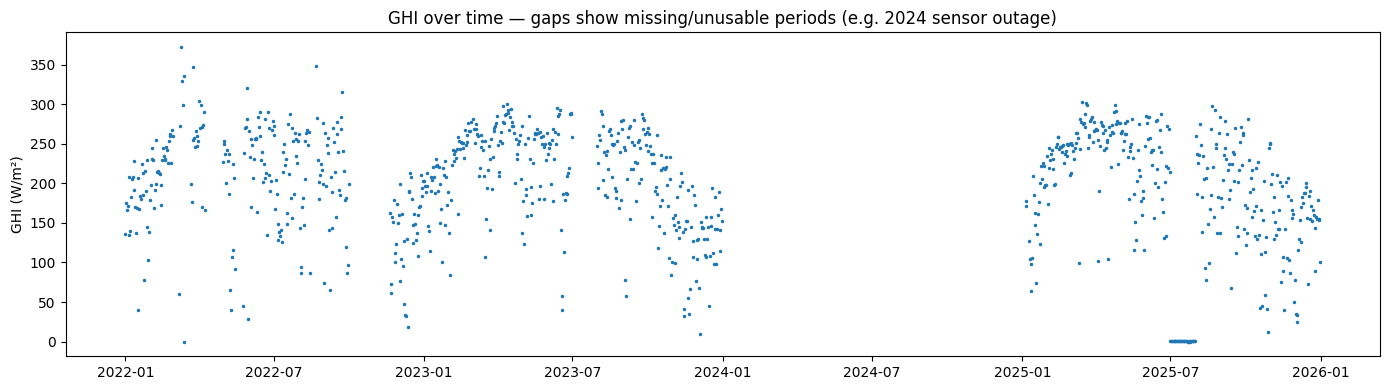

In [ ]:
TARGET = 'GHI_W_Avg_mean'
LEAK_COLS = ['GHI_W_Avg_min', 'GHI_W_Avg_max', 'GHI_W_Avg_std']

print("Missing target by year:")
print(df.groupby(df['Timestamp'].dt.year)[TARGET].apply(lambda s: s.isnull().sum()))

print(f"\nTotal rows: {len(df)} | Rows with valid target: {df[TARGET].notnull().sum()}")
print(f"\nTarget stats (valid rows): \n{df[TARGET].describe()}")

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df['Timestamp'], df[TARGET], '.', markersize=3)
ax.set_title('GHI over time — gaps show missing/unusable periods (e.g. 2024 sensor outage)')
ax.set_ylabel('GHI (W/m²)')
plt.tight_layout()
plt.show()


## 4. Clean and engineer features

- Drop rows with no target (can't train/evaluate without ground truth).
- Drop leakage columns.
- Physically-informed imputation for cloud layer columns (missing layer ≠ missing sensor reading).
- Median-impute the few remaining genuine single-day gaps.

In [ ]:
data = df.dropna(subset=[TARGET]).reset_index(drop=True)
print(f"Usable rows after dropping missing-target rows: {len(data)}")

X = data.drop(columns=LEAK_COLS + ['Timestamp', TARGET])
y = data[TARGET]
timestamps = data['Timestamp']

# Cloud layer 2/3: missing = that layer wasn't detected, not a sensor gap
l2l3_cover = [c for c in X.columns if ('CloudCover_L2' in c or 'CloudCover_L3' in c)]
l2l3_height = [c for c in X.columns if ('CloudBaseHeight_L2' in c or 'CloudBaseHeight_L3' in c)]

for c in l2l3_cover:
    X[c + '_missing'] = X[c].isnull().astype(int)
    X[c] = X[c].fillna(0)
for c in l2l3_height:
    X[c] = X[c].fillna(X[c].max())

# Remaining genuine single-day gaps -> median impute
remaining = X.columns[X.isnull().any()]
for c in remaining:
    X[c] = X[c].fillna(X[c].median())

print(f"Final feature matrix: {X.shape}")
assert X.isnull().sum().sum() == 0, "Unexpected NaNs remain"


Usable rows after dropping missing-target rows: 957
Final feature matrix: (957, 77)


## 5. Train / test split (chronological)

A **chronological split** is used instead of a random split: daily weather rows are
autocorrelated with their neighbors, so a random split would leak information from
test-adjacent days into training and overstate accuracy. The most recent ~15% of
usable days are held out as the test set, simulating real forward-prediction use.

In [ ]:
SPLIT_FRAC = 0.85
n = len(X)
split_idx = int(n * SPLIT_FRAC)

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"Train: {X_train.shape[0]} rows ({timestamps.iloc[0].date()} to {timestamps.iloc[split_idx-1].date()})")
print(f"Test:  {X_test.shape[0]} rows ({timestamps.iloc[split_idx].date()} to {timestamps.iloc[-1].date()})")


Train: 813 rows (2022-01-01 to 2025-08-09)
Test:  144 rows (2025-08-10 to 2025-12-31)


## 6. Train candidate models

Random Forest, XGBoost, and LightGBM are trained and compared on the chronological holdout.
With under 1,000 rows and 70+ features, heavily regularized models tend to generalize best
this is verified empirically below rather than assumed.

In [ ]:
def evaluate(name, model, Xtr, ytr, Xte, yte, verbose=True):
    model.fit(Xtr, ytr)
    pred = model.predict(Xte)
    mae = mean_absolute_error(yte, pred)
    rmse = mean_squared_error(yte, pred) ** 0.5
    r2 = r2_score(yte, pred)
    if verbose:
        print(f"{name:20s} MAE={mae:7.2f}  RMSE={rmse:7.2f}  R2={r2:.3f}")
    return model, pred, {'mae': mae, 'rmse': rmse, 'r2': r2}

candidates = {
    'RandomForest': RandomForestRegressor(
        n_estimators=400, max_depth=7, min_samples_leaf=2,
        random_state=42, n_jobs=-1
    ),
    'XGBoost': xgb.XGBRegressor(
        n_estimators=400, max_depth=4, learning_rate=0.03,
        subsample=0.8, colsample_bytree=0.8,
        reg_alpha=0.5, reg_lambda=1.0, random_state=42
    ),
    'LightGBM': lgb.LGBMRegressor(
        n_estimators=400, max_depth=4, learning_rate=0.03,
        subsample=0.8, colsample_bytree=0.8,
        reg_alpha=0.5, reg_lambda=1.0, random_state=42, verbose=-1
    ),
}

results = {}
fitted_models = {}
for name, model in candidates.items():
    fitted, pred, metrics = evaluate(name, model, X_train, y_train, X_test, y_test)
    results[name] = metrics
    fitted_models[name] = fitted

# Simple average ensemble of all three
avg_pred = np.mean([m.predict(X_test) for m in fitted_models.values()], axis=0)
results['Ensemble (avg)'] = {
    'mae': mean_absolute_error(y_test, avg_pred),
    'rmse': mean_squared_error(y_test, avg_pred) ** 0.5,
    'r2': r2_score(y_test, avg_pred),
}
print(f"{'Ensemble (avg)':20s} MAE={results['Ensemble (avg)']['mae']:7.2f}  "
      f"RMSE={results['Ensemble (avg)']['rmse']:7.2f}  R2={results['Ensemble (avg)']['r2']:.3f}")


RandomForest         MAE=  13.27  RMSE=  16.62  R2=0.929
XGBoost              MAE=  14.68  RMSE=  18.00  R2=0.917
LightGBM             MAE=  13.62  RMSE=  17.28  R2=0.923
Ensemble (avg)       MAE=  13.34  RMSE=  16.59  R2=0.929


In [ ]:
# Auto-select the best model by test MAE
results_df = pd.DataFrame(results).T.sort_values('mae')
print(results_df)

best_name = results_df.index[0]
print(f"\nBest model on holdout: {best_name}")


                      mae       rmse        r2
RandomForest    13.268366  16.624052  0.928899
Ensemble (avg)  13.336806  16.586942  0.929216
LightGBM        13.621470  17.281749  0.923162
XGBoost         14.684250  18.000040  0.916642

Best model on holdout: RandomForest


## 7. Stacked ensemble (Ridge meta-learner)

A stacking approach is also tested for completeness. On this dataset size it does **not**
reliably beat the best single model (there isn't enough data for the meta-learner to find a
stable combination) — the cell below shows this honestly rather than forcing a more complex
model into production.

In [ ]:
kf = KFold(n_splits=5, shuffle=False)
base_for_stack = {
    'rf': RandomForestRegressor(n_estimators=400, max_depth=7, min_samples_leaf=2, random_state=42, n_jobs=-1),
    'xgb': xgb.XGBRegressor(n_estimators=400, max_depth=4, learning_rate=0.03, subsample=0.8,
                              colsample_bytree=0.8, reg_alpha=0.5, reg_lambda=1.0, random_state=42),
    'lgb': lgb.LGBMRegressor(n_estimators=400, max_depth=4, learning_rate=0.03, subsample=0.8,
                               colsample_bytree=0.8, reg_alpha=0.5, reg_lambda=1.0, random_state=42, verbose=-1),
}

oof = {name: np.zeros(len(X_train)) for name in base_for_stack}
test_preds_stack = {}
for name, proto in base_for_stack.items():
    for tr_idx, val_idx in kf.split(X_train):
        m = type(proto)(**proto.get_params())
        m.fit(X_train.iloc[tr_idx], y_train.iloc[tr_idx])
        oof[name][val_idx] = m.predict(X_train.iloc[val_idx])
    proto.fit(X_train, y_train)
    test_preds_stack[name] = proto.predict(X_test)

meta = RidgeCV(alphas=[0.01, 0.1, 1.0, 10.0])
meta.fit(pd.DataFrame(oof), y_train)
stack_pred = meta.predict(pd.DataFrame(test_preds_stack))

stack_mae = mean_absolute_error(y_test, stack_pred)
stack_r2 = r2_score(y_test, stack_pred)
print(f"Stacked Ensemble  MAE={stack_mae:.2f}  R2={stack_r2:.3f}")
print(f"Best single model ({best_name})  MAE={results_df.loc[best_name,'mae']:.2f}  R2={results_df.loc[best_name,'r2']:.3f}")

if stack_mae < results_df.loc[best_name, 'mae']:
    print("\nStacking improves on the best single model — consider using it.")
else:
    print("\nStacking does NOT improve on the best single model here — use the simpler model.")


Stacked Ensemble  MAE=15.37  R2=0.903
Best single model (RandomForest)  MAE=13.27  R2=0.929

Stacking does NOT improve on the best single model here — use the simpler model.


## 8. Feature importance & SHAP explainability

Understand what's driving predictions. `Suntime_Tot_sum` (recorded sunshine duration) is
expected to dominate — it's almost a direct proxy for irradiance — but check the rest for
sanity (cloud cover negative, visibility/temperature positive is physically expected).

Top 15 features:
Suntime_Tot_sum             0.848004
month_cos                   0.032078
doy_cos                     0.030315
AirTemp_C_max               0.011903
Visibility_miles_mean       0.011336
AirTemp_C_std               0.007389
RH_pct_std                  0.003591
ApparentTemp_F_mean         0.003066
Visibility_miles_max        0.002907
ApparentTemp_F_std          0.002887
CloudCover_L2_oktas_mean    0.002630
CloudCover_L1_oktas_mean    0.002551
ApparentTemp_F_max          0.002539
Visibility_miles_std        0.002454
cloud_transmission_index    0.002311
dtype: float64


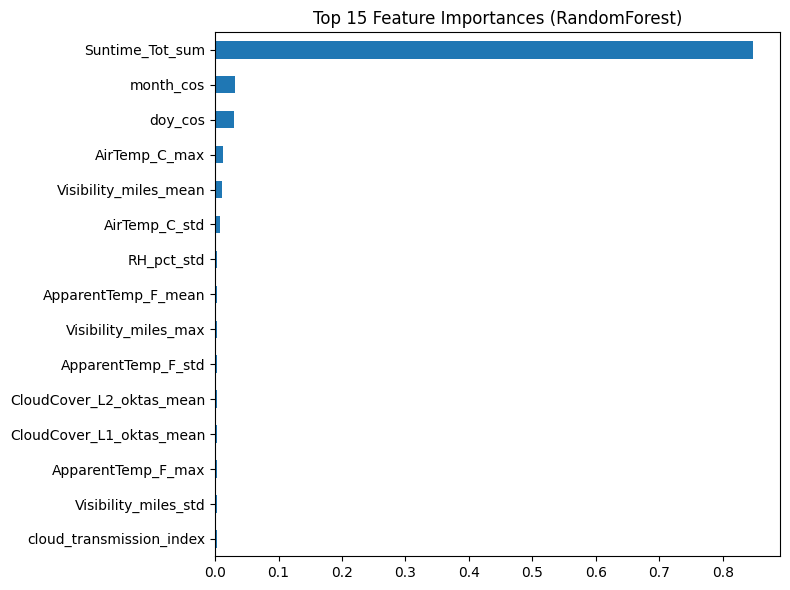

In [ ]:
best_model = fitted_models[best_name] if best_name in fitted_models else fitted_models['RandomForest']

importances = pd.Series(best_model.feature_importances_, index=X.columns).sort_values(ascending=False)
print("Top 15 features:")
print(importances.head(15))

fig, ax = plt.subplots(figsize=(8, 6))
importances.head(15).iloc[::-1].plot(kind='barh', ax=ax)
ax.set_title(f'Top 15 Feature Importances ({best_name})')
plt.tight_layout()
plt.show()


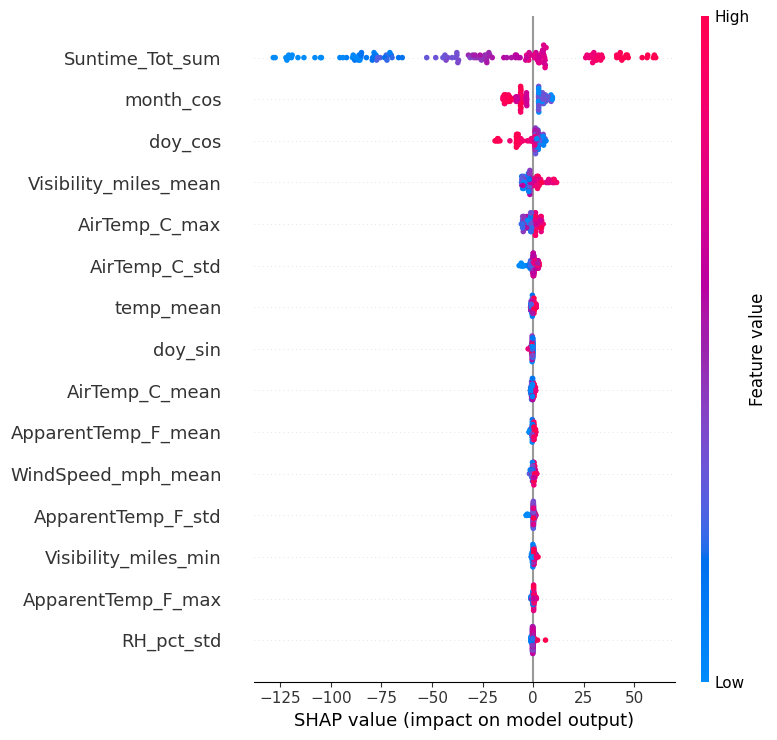

In [ ]:
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test, max_display=15, show=True)


## 9. Weather-only variant (no `Suntime_Tot_sum`)

Use this variant when sunshine-duration sensor data won't be available at prediction time
(e.g. predicting from weather forecast inputs only, rather than from your own ground station).
Expect noticeably lower accuracy — this is reported honestly so you know the real trade-off.

In [ ]:
X_train_ns = X_train.drop(columns=['Suntime_Tot_sum'])
X_test_ns = X_test.drop(columns=['Suntime_Tot_sum'])

ns_candidates = {
    'RandomForest': RandomForestRegressor(n_estimators=400, max_depth=7, min_samples_leaf=2, random_state=42, n_jobs=-1),
    'XGBoost': xgb.XGBRegressor(n_estimators=400, max_depth=4, learning_rate=0.03, subsample=0.8,
                                  colsample_bytree=0.8, reg_alpha=0.5, reg_lambda=1.0, random_state=42),
    'LightGBM': lgb.LGBMRegressor(n_estimators=400, max_depth=4, learning_rate=0.03, subsample=0.8,
                                    colsample_bytree=0.8, reg_alpha=0.5, reg_lambda=1.0, random_state=42, verbose=-1),
}

ns_results = {}
ns_fitted = {}
for name, model in ns_candidates.items():
    fitted, pred, metrics = evaluate(f"{name} (no Suntime)", model, X_train_ns, y_train, X_test_ns, y_test)
    ns_results[name] = metrics
    ns_fitted[name] = fitted

ns_results_df = pd.DataFrame(ns_results).T.sort_values('mae')
best_ns_name = ns_results_df.index[0]
print(f"\nBest weather-only model: {best_ns_name}")


RandomForest (no Suntime) MAE=  26.72  RMSE=  34.25  R2=0.698
XGBoost (no Suntime) MAE=  33.52  RMSE=  44.17  R2=0.498
LightGBM (no Suntime) MAE=  46.41  RMSE=  60.17  R2=0.069

Best weather-only model: RandomForest


## 10. Predicted vs. actual (best full model)

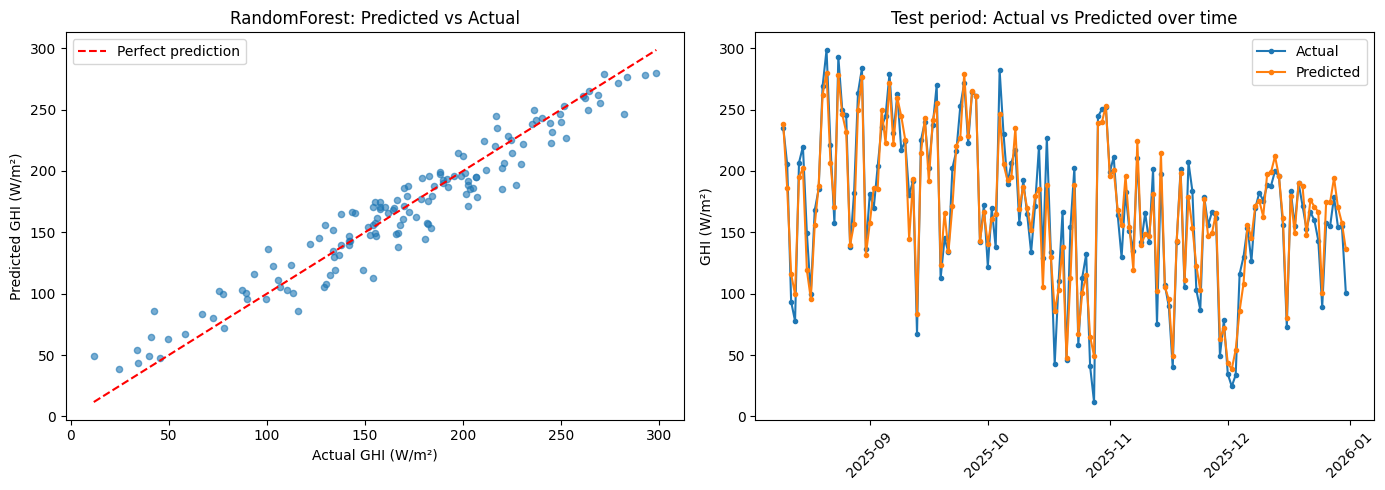

In [ ]:
best_pred = best_model.predict(X_test)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test, best_pred, alpha=0.6, s=20)
lims = [min(y_test.min(), best_pred.min()), max(y_test.max(), best_pred.max())]
axes[0].plot(lims, lims, 'r--', label='Perfect prediction')
axes[0].set_xlabel('Actual GHI (W/m²)')
axes[0].set_ylabel('Predicted GHI (W/m²)')
axes[0].set_title(f'{best_name}: Predicted vs Actual')
axes[0].legend()

axes[1].plot(timestamps.iloc[split_idx:].values, y_test.values, label='Actual', marker='.')
axes[1].plot(timestamps.iloc[split_idx:].values, best_pred, label='Predicted', marker='.')
axes[1].set_title('Test period: Actual vs Predicted over time')
axes[1].set_ylabel('GHI (W/m²)')
axes[1].legend()
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


## 11. Deployable `GHIPredictor` class

Wraps preprocessing + the trained model so you can call `.predict()` on new daily weather
records without re-deriving the cleaning logic by hand. Trains both the full (with Suntime)
and weather-only variants and lets you pick at prediction time.

In [ ]:
def _default_ghi_model():
    """Module-level factory (not a lambda) so GHIPredictor instances remain picklable."""
    return RandomForestRegressor(n_estimators=400, max_depth=7, min_samples_leaf=2,
                                   random_state=42, n_jobs=-1)


class GHIPredictor:
    """
    Production wrapper for GHI prediction.

    Usage:
        predictor = GHIPredictor()
        predictor.fit(df)                      # df = raw Daily_Data dataframe
        predictor.predict(new_df)               # uses full model (needs Suntime_Tot_sum)
        predictor.predict(new_df, weather_only=True)  # no Suntime needed
    """

    LEAK_COLS = ['GHI_W_Avg_min', 'GHI_W_Avg_max', 'GHI_W_Avg_std']
    TARGET = 'GHI_W_Avg_mean'

    def __init__(self, model_factory=None, model_factory_ns=None):
        self.model_factory = model_factory or _default_ghi_model
        self.model_factory_ns = model_factory_ns or self.model_factory
        self.model_ = None
        self.model_ns_ = None
        self.feature_cols_ = None
        self.feature_cols_ns_ = None
        self._impute_medians = {}
        self._height_max = {}

    def _clean(self, df, fit_mode=False):
        df = df.copy()
        drop_cols = [c for c in self.LEAK_COLS + ['Timestamp', self.TARGET] if c in df.columns]
        X = df.drop(columns=drop_cols)

        l2l3_cover = [c for c in X.columns if ('CloudCover_L2' in c or 'CloudCover_L3' in c)]
        l2l3_height = [c for c in X.columns if ('CloudBaseHeight_L2' in c or 'CloudBaseHeight_L3' in c)]

        for c in l2l3_cover:
            X[c + '_missing'] = X[c].isnull().astype(int)
            X[c] = X[c].fillna(0)
        for c in l2l3_height:
            if fit_mode:
                self._height_max[c] = X[c].max()
            X[c] = X[c].fillna(self._height_max.get(c, X[c].max()))

        remaining = X.columns[X.isnull().any()]
        for c in remaining:
            if fit_mode:
                self._impute_medians[c] = X[c].median()
            X[c] = X[c].fillna(self._impute_medians.get(c, X[c].median()))

        return X

    def fit(self, df):
        data = df.dropna(subset=[self.TARGET]).reset_index(drop=True)
        X = self._clean(data, fit_mode=True)
        y = data[self.TARGET]

        self.feature_cols_ = X.columns.tolist()
        self.model_ = self.model_factory()
        self.model_.fit(X, y)

        X_ns = X.drop(columns=['Suntime_Tot_sum']) if 'Suntime_Tot_sum' in X.columns else X
        self.feature_cols_ns_ = X_ns.columns.tolist()
        self.model_ns_ = self.model_factory_ns()
        self.model_ns_.fit(X_ns, y)

        return self

    def predict(self, df, weather_only=False):
        X = self._clean(df, fit_mode=False)
        if weather_only:
            X = X.reindex(columns=self.feature_cols_ns_, fill_value=0)
            return self.model_ns_.predict(X)
        X = X.reindex(columns=self.feature_cols_, fill_value=0)
        return self.model_.predict(X)

    def feature_importance(self, weather_only=False):
        model = self.model_ns_ if weather_only else self.model_
        cols = self.feature_cols_ns_ if weather_only else self.feature_cols_
        return pd.Series(model.feature_importances_, index=cols).sort_values(ascending=False)


In [ ]:
# Fit the deployable predictor on the full usable dataset (train + test combined)
predictor = GHIPredictor()
predictor.fit(data)

print("Top 10 features (full model):")
print(predictor.feature_importance().head(10))
print()
print("Top 10 features (weather-only model):")
print(predictor.feature_importance(weather_only=True).head(10))


Top 10 features (full model):
Suntime_Tot_sum          0.842401
month_cos                0.038403
doy_cos                  0.022328
AirTemp_C_max            0.019376
Visibility_miles_mean    0.011673
AirTemp_C_std            0.007455
ApparentTemp_F_max       0.006218
RH_pct_std               0.003178
Visibility_miles_max     0.003059
AirTemp_C_mean           0.002603
dtype: float64

Top 10 features (weather-only model):
RH_pct_std                  0.160012
humidity_range              0.151182
AirTemp_C_std               0.093468
cloud_transmission_index    0.067032
cloud_total_mean            0.064221
Visibility_miles_mean       0.053830
month_cos                   0.048885
doy_cos                     0.044605
doy_sin                     0.017750
ApparentTemp_F_std          0.016898
dtype: float64


In [ ]:
import pickle
with open('ghi_predictor.pkl', 'wb') as f:
    pickle.dump(predictor, f)
print("Saved trained predictor to ghi_predictor.pkl")

# Example: predict on the last 5 rows of the dataset (as if they were new data)
sample = data.tail(5).drop(columns=[GHIPredictor.TARGET])
print("\nSample predictions (full model):", predictor.predict(sample))
print("Sample predictions (weather-only):", predictor.predict(sample, weather_only=True))
print("Actual values:", data.tail(5)[GHIPredictor.TARGET].values)


Saved trained predictor to ghi_predictor.pkl

Sample predictions (full model): [166.09068868 183.21524826 164.87846625 157.0876744  122.38754172]
Sample predictions (weather-only): [158.28869957 175.92910345 159.91003923 149.66155558 164.55787955]
Actual values: [154.93984028 178.88185417 154.27745139 155.35854861 100.77886806]


In [ ]:
test_rows = df.iloc[1190:1400]

actual_ghi = test_rows[GHIPredictor.TARGET]
predicted_ghi = predictor.predict(test_rows)

# Create a DataFrame to display the comparison
comparison_df = pd.DataFrame({
    'Timestamp': test_rows['Timestamp'],
    'Actual GHI': actual_ghi,
    'Predicted GHI': predicted_ghi
})

print("Predicted vs. Actual GHI for rows 1210-1230:")
print(comparison_df.set_index('Timestamp'))
comparison_df.to_csv("output.csv")

Predicted vs. Actual GHI for rows 1210-1230:
            Actual GHI  Predicted GHI
Timestamp                            
2025-04-05  190.220854     192.102362
2025-04-06  247.874250     262.595936
2025-04-07  277.686194     273.716398
2025-04-08  274.462653     264.695115
2025-04-09  273.040021     264.098152
...                ...            ...
2025-10-27   40.762007      52.355635
2025-10-28   11.708729      25.983668
2025-10-29  244.413556     243.393856
2025-10-30  250.159854     244.543507
2025-10-31  251.737722     251.438870

[210 rows x 2 columns]
